So the data has frequency in Hz and R_V_mean which is the lock-in R output (magnitude of the signal) in Volts. Since we're measuring with 1 Vpp and high impedance, I need to think about how to convert this to impedance.
Actually, the lock-in amplifier measures the voltage across the device. If we're in a specific circuit configuration... Let me think about this.
The lock-in measures the amplitude of the signal. With a 1 Vpp source, the R_V_mean would be the RMS amplitude of the voltage across... what exactly? We need to know the measurement setup to convert to impedance.
Wait, the R_V_mean values are quite small (max ~0.065 V). With 1 Vpp (0.5 V amplitude, ~0.354 Vrms), these voltages are much smaller. This suggests we're measuring voltage across a series resistor, or across the crystal in a divider configuration.
Actually, looking at the data more carefully - the values go through what looks like a resonance curve (they peak at some frequency). Near resonance of a crystal, the impedance drops to a minimum (series resonance) and rises to a maximum (parallel/anti-resonance).
Let me think about the measurement setup. With a lock-in amplifier:

The function generator drives the circuit
The lock-in measures the output

A typical setup for crystal impedance measurement would be:

Series resistor method: Vsource in series with Rseries and crystal. Measure voltage across the crystal or across Rseries.

Since the user says "high impedance" setting and 1 Vpp sinusoidal, and the R values (which are the magnitude output of the lock-in - the R in the X+jY or R,θ output format) peak around 0.065 V near the resonance...
Actually wait - the R_V_mean values are quite small across most of the range and peak near resonance. This is suspicious. Let me look at the shape more carefully.
If the measurement is voltage across a series resistor (the crystal being the unknown), then large R means high current = low crystal impedance (at series resonance).
…

Now I understand the data. Let me analyze what we have:

The R_V_mean is the lock-in R output in Volts (amplitude of the signal)
Peak is at ~50096.3 Hz (this should be series resonance fs)
Minimum is at ~50284.5 Hz (this should be anti-resonance fp)

Wait, this is interesting. The peak voltage corresponds to maximum current through the crystal, which happens at series resonance (minimum impedance). The minimum voltage corresponds to minimum current, which happens at anti-resonance (maximum impedance).
But wait - what is the lock-in measuring exactly? In high impedance mode, the lock-in is measuring the voltage at its input. If the crystal is connected between the function generator output and the lock-in input, we're measuring the voltage across the crystal directly.
But with high impedance input, the lock-in doesn't draw much current. The question is: is there a series resistor in the circuit?
Actually, thinking about this more carefully: if we have a voltage divider with a series resistor Rs and the crystal as the load, measured in high impedance mode:

V_crystal = V_source × Z_crystal / (Rs + Z_crystal)
When Z_crystal >> Rs (far from resonance): V_crystal ≈ V_source
When Z_crystal is minimum (series resonance): V_crystal is minimum
When Z_crystal is maximum (anti-resonance): V_crystal is maximum

But that's the opposite of what we see! The voltage PEAKS at the frequency I'd expect to be series resonance and is MINIMUM at anti-resonance.
So maybe the lock-in is measuring the voltage across the series resistor Rs:

V_Rs = V_source × Rs / (Rs + Z_crystal)
When Z_crystal is minimum (series resonance): V_Rs is maximum ← This matches!
When Z_crystal is maximum (anti-resonance): V_Rs is minimum ← This matches!

So the setup is: Function generator → Series resistor Rs → Crystal → back to FG. Lock-in measures across the series resistor.
This makes sense! It's a current-sensing configuration. …

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit, minimize
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('processed_data.csv')
freq = df['frequency_Hz'].values
V_meas = df['R_V_mean'].values

# Source: 1 Vpp => 0.5 Vpeak => 0.5/sqrt(2) Vrms
V_source = 0.5 / np.sqrt(2)

def Z_BVD(f, R1, C1, L1, C0):
    w = 2 * np.pi * f
    Z_motional = R1 + 1j*(w*L1 - 1/(w*C1))
    Z_C0 = 1 / (1j * w * C0)
    Z_crystal = (Z_motional * Z_C0) / (Z_motional + Z_C0)
    return Z_crystal

def V_sense(f, R1, C1, L1, C0, Rs):
    Z_xtal = Z_BVD(f, R1, C1, L1, C0)
    Z_total = Rs + Z_xtal
    return V_source * Rs / np.abs(Z_total)

# Initial guesses from analytics
fs = 50096.3
fp = 50284.5
ratio = (fp/fs)**2 - 1  # C1/C0
print(f"C1/C0 ratio: {ratio:.6f}")

# Fix C0, compute C1, L1
C0_guess = 5e-12
C1_guess = ratio * C0_guess
ws = 2*np.pi*fs
L1_guess = 1 / (ws**2 * C1_guess)

print(f"Initial: C0={C0_guess*1e12:.2f} pF, C1={C1_guess*1e15:.2f} fF, L1={L1_guess:.1f} H")

# Estimate Rs from off-resonance behavior (well below resonance)
# V_Rs ≈ V_source * Rs * w * C0 (for Rs << Z_C0)
mask_low = freq < 49600
w_low = 2*np.pi*freq[mask_low]
# Rs * C0 ≈ V_meas / (V_source * w)
RC_product = np.mean(V_meas[mask_low] / (V_source * w_low))
print(f"Rs*C0 product estimate: {RC_product:.4e}")
Rs_guess = RC_product / C0_guess
print(f"Rs guess: {Rs_guess:.1f} Ohm2")

# At series resonance, V_peak = V_source * Rs / (Rs + R1)
V_peak = 0.065040
R1_guess = Rs_guess * (V_source/V_peak - 1)
print(f"R1 guess: {R1_guess:.1f} Ohm")

# Full optimization
from scipy.optimize import minimize

def residual(params):
    log_R1, log_C1, log_L1, log_C0, log_Rs = params
    R1 = np.exp(log_R1)
    C1 = np.exp(log_C1)
    L1 = np.exp(log_L1)
    C0 = np.exp(log_C0)
    Rs = np.exp(log_Rs)
    V_pred = V_sense(freq, R1, C1, L1, C0, Rs)
    # Log-scale residuals (better for multi-decade data)
    res = np.log(V_pred + 1e-10) - np.log(V_meas + 1e-10)
    return np.sum(res**2)

x0 = [np.log(R1_guess), np.log(C1_guess), np.log(L1_guess), 
      np.log(C0_guess), np.log(Rs_guess)]

result = minimize(residual, x0, method='Nelder-Mead', 
                  options={'maxiter': 100000, 'xatol': 1e-8, 'fatol': 1e-10})

R1_fit = np.exp(result.x[0])
C1_fit = np.exp(result.x[1])
L1_fit = np.exp(result.x[2])
C0_fit = np.exp(result.x[3])
Rs_fit = np.exp(result.x[4])

print("\n=== FIT RESULTS ===")
print(f"R1 = {R1_fit:.2f} Ohm")
print(f"C1 = {C1_fit*1e15:.3f} fF")
print(f"L1 = {L1_fit:.2f} H")
print(f"C0 = {C0_fit*1e12:.4f} pF")
print(f"Rs = {Rs_fit:.2f} Ohm")
print(f"Converged: {result.success}, fun={result.fun:.4f}")

# Verify resonance frequencies
fs_check = 1/(2*np.pi*np.sqrt(L1_fit*C1_fit))
fp_check = fs_check * np.sqrt(1 + C1_fit/C0_fit)
print(f"\nfs check: {fs_check:.3f} Hz (target: {fs:.1f})")
print(f"fp check: {fp_check:.3f} Hz (target: {fp:.1f})")

Q = 2*np.pi*fs_check*L1_fit / R1_fit
print(f"Q factor: {Q:.0f}")


C1/C0 ratio: 0.007528
Initial: C0=5.00 pF, C1=37.64 fF, L1=268.2 H
Rs*C0 product estimate: 1.0133e-08
Rs guess: 2026.5 Ohm2
R1 guess: 8989.5 Ohm

=== FIT RESULTS ===
R1 = 5260.12 Ohm
C1 = 37.620 fF
L1 = 268.29 H
C0 = 4.9975 pF
Rs = 1482.51 Ohm
Converged: True, fun=2.0346

fs check: 50096.293 Hz (target: 50096.3)
fp check: 50284.494 Hz (target: 50284.5)
Q factor: 16055


Hmm, the initial guess for R1 gave me ~9000 Ω but the fit converged to ~5260 Ω. The residual is 2.03 on the log-scale. Let me check the quality of the fit more carefully and also try different optimization approaches.
Actually, I'm slightly worried about the Rs_guess formula I used. Let me reconsider.
At series resonance, in the voltage divider with Rs and Z_crystal:

Z_crystal at fs = R1 (purely real, imaginary parts cancel)
V_Rs = V_source * Rs / (Rs + R1)
V_peak = V_source * Rs / (Rs + R1)
V_peak / V_source = Rs / (Rs + R1)
Rs + R1 = V_source * Rs / V_peak
R1 = Rs * (V_source/V_peak - 1)

V_source = 0.5/√2 = 0.3536 Vrms
V_peak = 0.065040 V (lock-in RMS output)
V_source/V_peak = 0.3536/0.065040 = 5.436
So R1 = Rs * (5.436 - 1) = Rs * 4.436
With Rs_guess = 2026.5 Ω: R1 = 2026.5 * 4.436 = 8989 Ω
With Rs_fit = 1482.5 Ω: R1 = 1482.5 * (0.3536/0.065040 - 1) = 1482.5 * 4.436 = 6578 Ω... but the fit gives R1 = 5260 Ω.
That's inconsistent. Let me check if the fit is actually good by looking at the predicted vs actual at the peak.
Actually, wait. The issue might be that the R1 formula I used assumes we're at exactly the minimum impedance point, but the peak of V_Rs is not exactly at the impedance minimum due to the interaction with C0. The anti-resonance also plays a role near the peak.
Let me improve the fit and check quality.
Also, R1 = 5260 Ω seems HIGH for a crystal resonator. Typical values are in the range of 10s to 100s of ohms for quartz crystals, though for tuning fork type crystals at 32 kHz range they can be higher (tens of kΩ).
For a 50 kHz crystal, R1 values of thousands of ohms are possible for low-frequency resonators. Let me calculate Q: Q = ωsL1/R1 = 2π50096*268.29/5260 ≈ 16,055. That's a reasonable Q for a quartz crystal.
But wait, I'm also slightly concerned about the fit quality. Let me check it more carefully with a plot and also look at whether the Nelder-Mead is really converged properly. …

In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, differential_evolution
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('processed_data.csv')
freq = df['frequency_Hz'].values
V_meas = df['R_V_mean'].values
V_source = 0.5 / np.sqrt(2)  # 1Vpp -> Vrms

def V_sense_model(f, R1, C1, L1, C0, Rs):
    w = 2 * np.pi * f
    Z_m = R1 + 1j*(w*L1 - 1.0/(w*C1))
    Z_C0 = 1.0 / (1j * w * C0)
    Z_xtal = (Z_m * Z_C0) / (Z_m + Z_C0)
    return V_source * Rs / np.abs(Rs + Z_xtal)

# Use the tight analytical constraints and only free up R1, C0, Rs
fs_target = 50096.3
fp_target = 50284.5
ratio = (fp_target/fs_target)**2 - 1  # C1/C0

def residual_tight(params):
    log_R1, log_C0, log_Rs = params
    R1 = np.exp(log_R1)
    C0 = np.exp(log_C0)
    Rs = np.exp(log_Rs)
    C1 = ratio * C0
    ws = 2*np.pi*fs_target
    L1 = 1.0/(ws**2 * C1)
    V_pred = V_sense_model(freq, R1, C1, L1, C0, Rs)
    return np.sum((np.log(V_pred + 1e-9) - np.log(V_meas + 1e-9))**2)

# Try a global search first
from scipy.optimize import differential_evolution
bounds = [
    (np.log(100), np.log(100000)),    # R1: 100 to 100k Ohm
    (np.log(0.5e-12), np.log(50e-12)), # C0: 0.5 to 50 pF
    (np.log(100), np.log(50000)),       # Rs: 100 to 50k Ohm
]
result_de = differential_evolution(residual_tight, bounds, maxiter=2000, tol=1e-10, seed=42, workers=1)
print(f"DE result: fun={result_de.fun:.5f}")

# Polish with Nelder-Mead
result = minimize(residual_tight, result_de.x, method='Nelder-Mead',
                  options={'maxiter': 200000, 'xatol': 1e-10, 'fatol': 1e-12})
print(f"NM polish: fun={result.fun:.5f}")

R1 = np.exp(result.x[0])
C0 = np.exp(result.x[1])
Rs = np.exp(result.x[2])
C1 = ratio * C0
ws = 2*np.pi*fs_target
L1 = 1.0/(ws**2 * C1)

print(f"\n=== FINAL BVD PARAMETERS ===")
print(f"R1  = {R1:.1f} Ω")
print(f"C1  = {C1*1e15:.3f} fF")
print(f"L1  = {L1:.2f} H")
print(f"C0  = {C0*1e12:.4f} pF")
print(f"Rs  = {Rs:.1f} Ω  (sense resistor, not a crystal param)")

Q = ws * L1 / R1
print(f"\nDerived:")
print(f"Q   = {Q:.0f}")
print(f"BW  = {fs_target/Q:.2f} Hz")

# Check predicted vs measured at key points
V_pred = V_sense_model(freq, R1, C1, L1, C0, Rs)
idx_peak = np.argmax(V_meas)
idx_min = np.argmin(V_meas)
print(f"\nAt series res: measured={V_meas[idx_peak]*1000:.3f} mV, predicted={V_pred[idx_peak]*1000:.3f} mV")
print(f"At anti-res:   measured={V_meas[idx_min]*1e6:.1f} µV, predicted={V_pred[idx_min]*1e6:.1f} µV")

# Save for plotting
np.savez('bvd_fit.npz', freq=freq, V_meas=V_meas, V_pred=V_pred,
         R1=R1, C1=C1, L1=L1, C0=C0, Rs=Rs, Q=Q)

DE result: fun=2.03490
NM polish: fun=2.03490

=== FINAL BVD PARAMETERS ===
R1  = 2043.6 Ω
C1  = 96.835 fF
L1  = 104.23 H
C0  = 12.8640 pF
Rs  = 575.9 Ω  (sense resistor, not a crystal param)

Derived:
Q   = 16054
BW  = 3.12 Hz

At series res: measured=65.040 mV, predicted=77.734 mV
At anti-res:   measured=5.6 µV, predicted=6.9 µV


The global optimization isn't converging well either - the predicted value at series resonance (77.7 mV) doesn't match the measured (65.0 mV) very well. This suggests there's a degeneracy in the parameter space that I need to resolve.
The issue is that Rs and C0 (and consequently R1) are degenerate - many combinations of (R1, C0, Rs) can give similar fits.
The problem is that the ratio Rs*C0 is constrained by the off-resonance behavior, and the ratio Rs/(Rs+R1) is constrained by the peak value, but neither Rs nor C0 is individually constrained without additional independent information.
Wait, actually the anti-resonance also gives information. At anti-resonance, the BVD impedance is maximum. Let me think...
The anti-resonance occurs when the motional branch and C0 are in parallel resonance. At anti-resonance:

The admittance of the crystal is minimum
Y_crystal(fp) = jωpC0 + 1/(R1 + j(ωpL1 - 1/(ωpC1)))

The real part of Y_crystal at anti-resonance:
Re(Y) = R1 / |Z_motional(fp)|^2
But this requires knowing R1.
Actually, let me think about this differently. The residual is 2.03 regardless of what DE does. That means we've found the global minimum of the log-residuals, but it's just that the fit isn't perfect (which could be because of measurement noise or model inadequacy).
But wait - the predicted peak is 77.7 mV vs measured 65.0 mV. That's a pretty big discrepancy. Let me see if the residual breakdown shows this is dominated by particular frequency regions.
Actually, the issue might be that the anti-resonance minimum is at the noise floor (6 µV), and the model has to "explain" both the noise floor level and the exact peak value. These place constraints on Rs relative to the crystal impedances.
Actually wait, I think there might be fundamentally 4 constraints from the data:

Off-resonance level (far below fs) → constrains Rs × C0
Peak level at fs → constrains Rs / (Rs + R1)
Position of fs → constrains L1 × C1
Position of fp → constrains C1/C0

In [3]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

df = pd.read_csv('processed_data.csv')
freq = df['frequency_Hz'].values
V_meas = df['R_V_mean'].values
V_source = 0.5 / np.sqrt(2)

# --- Step 1: Measure bandwidth of the peak (loaded Q) ---
V_peak = V_meas.max()
f_peak = freq[V_meas.argmax()]
V_3dB = V_peak / np.sqrt(2)
print(f"V_peak = {V_peak*1000:.4f} mV at f = {f_peak:.2f} Hz")
print(f"V_3dB  = {V_3dB*1000:.4f} mV")

# Find left and right 3dB points via interpolation
# Left side (below peak)
mask_left = (freq < f_peak) & (freq > 49800)
f_left_interp = interp1d(V_meas[mask_left], freq[mask_left])
f_left = float(f_left_interp(V_3dB))

# Right side (above peak, before anti-resonance dip)
mask_right = (freq > f_peak) & (freq < 50200)
f_right_interp = interp1d(V_meas[mask_right][::-1], freq[mask_right][::-1])
f_right = float(f_right_interp(V_3dB))

delta_f = f_right - f_left
print(f"\n3dB frequencies: {f_left:.2f} Hz (left), {f_right:.2f} Hz (right)")
print(f"Loaded BW = {delta_f:.2f} Hz")
Q_loaded = f_peak / delta_f
print(f"Q_loaded = {Q_loaded:.0f}")

# --- Step 2: Get Rs/R1 ratio from peak amplitude ---
p = V_peak / V_source
print(f"\nV_peak/V_source = {p:.5f}")
Rs_over_R1 = p / (1 - p)
print(f"Rs/R1 = {Rs_over_R1:.5f}")
print(f"R1/Rs = {1/Rs_over_R1:.4f}")

# --- Step 3: Bandwidth gives (Rs+R1)/L1 ---
# delta_omega = (Rs+R1)/L1
# Rs+R1 = delta_omega * L1
# L1 depends on C0. Let's use the ratio approach.
# 
# Q_loaded = ws*L1/(Rs+R1) = ws*L1/(R1*(1+Rs/R1)) = Q_crystal/(1+Rs/R1)
# Q_crystal = Q_loaded * (1 + R1/Rs) / ... 

# Actually Q_loaded from V_Rs bandwidth:
# Q_loaded = fs / delta_f = ws*L1/(Rs+R1)
# Q_crystal = ws*L1/R1 = Q_loaded * (1+Rs/R1) * R1/R1 ... 

# Q_loaded = ws*L1/(Rs+R1), Q_crystal = ws*L1/R1
# Q_crystal = Q_loaded * (Rs+R1)/R1 = Q_loaded * (1 + Rs/R1)

Rs_R1_ratio = Rs_over_R1  # Rs/R1
Q_crystal = Q_loaded * (1 + 1/Rs_R1_ratio)  # multiply by (Rs+R1)/R1 = 1/p
print(f"\nQ_crystal = Q_loaded * (1 + R1/Rs)")
print(f"Q_crystal = {Q_loaded:.1f} * {1 + 1/Rs_R1_ratio:.4f} = {Q_crystal:.0f}")

# Now determine R1 from C0:
# Q_crystal = ws*L1/R1, and L1 = 1/(ws^2*C1), C1 = ratio*C0
# So Q_crystal = 1/(ws*R1*C1) = 1/(ws*R1*ratio*C0)
# Rs*C0 = RC_product (from off-resonance)
# Rs = Rs/R1 * R1  => R1 = Rs / (Rs/R1)
# R1*C0 = (Rs*C0) / (Rs/R1) = RC_product * (R1/Rs)

fs_target = 50096.3
ws = 2*np.pi*fs_target
ratio_C1C0 = (50284.5/50096.3)**2 - 1

# From Q_crystal: R1 = 1/(ws*ratio*C0*Q_crystal)
# From RC_product: Rs = RC_product/C0
# Rs/R1 = RC_product/C0 * ws*ratio*C0*Q_crystal = RC_product*ws*ratio*Q_crystal

mask_low = freq < 49600
w_low = 2*np.pi*freq[mask_low]
RC_product = np.mean(V_meas[mask_low] / (V_source * w_low))
print(f"\nRC_product (Rs*C0) = {RC_product:.4e}")

# Rs/R1 should equal RC_product * ws * ratio * Q_crystal
Rs_R1_check = RC_product * ws * ratio_C1C0 * Q_crystal
print(f"Rs/R1 from equations = {Rs_R1_check:.5f}")
print(f"Rs/R1 from peak amp  = {Rs_over_R1:.5f}")

# These should be equal, let's see how close they are.
# If they're not equal, it's because we have noise / non-ideal behavior.
# Use the geometric mean to get a consistent set of params:

# Let's solve it: we have two estimates of Rs/R1. 
# True values: enforce both simultaneously
# From bandwidth: Q_crystal = Q_loaded / p  (since Rs/(Rs+R1) = p)
Q_crystal_final = Q_loaded / p
print(f"\nQ_crystal (method 2: Q_loaded/p) = {Q_crystal_final:.1f}")

# Use Q_crystal_final
# R1 = 1/(ws * ratio * C0 * Q_crystal_final)
# Rs/R1 = p/(1-p)
# Rs * C0 = RC_product → C0 = RC_product/Rs = RC_product*(1-p)/(p*R1)
# Substituting into R1 equation:
# R1 = 1/(ws * ratio * [RC_product*(1-p)/(p*R1)] * Q_crystal_final)
# R1^2 = p / (ws * ratio * RC_product * (1-p) * Q_crystal_final)

R1_sq = p / (ws * ratio_C1C0 * RC_product * (1-p) * Q_crystal_final)
R1_final = np.sqrt(R1_sq)
Rs_final = Rs_over_R1 * R1_final
C0_final = RC_product / Rs_final
C1_final = ratio_C1C0 * C0_final
L1_final = 1.0/(ws**2 * C1_final)

print(f"\n=== FINAL PARAMS (analytical) ===")
print(f"R1  = {R1_final:.1f} Ω")
print(f"C1  = {C1_final*1e15:.3f} fF")
print(f"L1  = {L1_final:.2f} H")
print(f"C0  = {C0_final*1e12:.4f} pF")
print(f"Rs  = {Rs_final:.1f} Ω  (sense resistor)")
print(f"Q   = {Q_crystal_final:.0f}")

# Verify
fp_check = fs_target * np.sqrt(1 + C1_final/C0_final)
print(f"\nfs check = {fs_target:.2f} Hz ✓")
print(f"fp check = {fp_check:.2f} Hz (data: 50284.5)")



V_peak = 65.0400 mV at f = 50096.30 Hz
V_3dB  = 45.9902 mV

3dB frequencies: 50093.78 Hz (left), 50098.69 Hz (right)
Loaded BW = 4.92 Hz
Q_loaded = 10189

V_peak/V_source = 0.18396
Rs/R1 = 0.22543
R1/Rs = 4.4359

Q_crystal = Q_loaded * (1 + R1/Rs)
Q_crystal = 10189.4 * 5.4359 = 55389

RC_product (Rs*C0) = 1.0133e-08
Rs/R1 from equations = 1.32981
Rs/R1 from peak amp  = 0.22543

Q_crystal (method 2: Q_loaded/p) = 55388.9

=== FINAL PARAMS (analytical) ===
R1  = 0.4 Ω
C1  = 821774.202 fF
L1  = 0.01 H
C0  = 109167.5424 pF
Rs  = 0.1 Ω  (sense resistor)
Q   = 55389

fs check = 50096.30 Hz ✓
fp check = 50284.50 Hz (data: 50284.5)


Something went very wrong with the analytical solution. The values are clearly nonphysical (Rs = 0.1 Ω, C0 = 109 µF). There must be an inconsistency in my equations.
The problem is that the two estimates of Rs/R1 are very different:

From peak amplitude: Rs/R1 = 0.225
From RC_product and bandwidth: Rs/R1 = 1.330

These are very different, meaning my equations are inconsistent. Let me figure out why.
The Rs/R1 from RC_product and bandwidth:
Rs/R1 = RC_product * ws * ratio * Q_crystal_final
= 1.0133e-8 * 2π * 50096.3 * 0.007528 * 55389
= 1.0133e-8 * 314,830 * 0.007528 * 55389
= 1.0133e-8 * 314,830 * 416.9
= 1.0133e-8 * 131,316,867
= 1.330
But from peak amplitude, Rs/R1 = 0.225.
These can't both be right simultaneously. The inconsistency suggests that the 3dB bandwidth measurement is not purely due to R1 and Rs, OR the off-resonance estimate of Rs*C0 is not accurate.
Actually, wait. Let me reconsider the 3dB bandwidth issue. In a loaded crystal circuit, the loaded Q isn't simply ws*L1/(Rs+R1). Let me rethink.
Near series resonance, the BVD admittance (ignoring C0 which has small effect near fs) is approximately:
Z_motional ≈ R1 + j2L1(ω-ωs)  (for small detuning)
The total circuit impedance:
Z_total = Rs + Z_xtal ≈ Rs + R1 + j2L1(ω-ωs)
|V_Rs|² = V_source² × Rs² / [(Rs+R1)² + 4L1²(ω-ωs)²]
At 3dB of V_Rs: 4L1²(ω-ωs)² = (Rs+R1)²
2L1|ω-ωs| = (Rs+R1)
Δω = (Rs+R1)/L1 (this is the full 3dB bandwidth)
So Q_loaded_V = ωs / Δω = ωsL1 / (Rs+R1)
This seems right. Let me verify with numbers:
Δω = 2π * 4.92 = 30.9 rad/s
Q_loaded = ωs/Δω = 2π*50096.3 / 30.9 = 314,830 / 30.9 = 10,186 ✓
Now (Rs+R1)/L1 = Δω
Rs+R1 = Δω × L1
L1 depends on C0: L1 = 1/(ws² × ratio × C0) = 1/(314830² × 0.007528 × C0)
Let's compute 1/(ws² × ratio) = 1/(314830² × 0.007528) = 1/(9.912e10 × 0.007528) = 1/(7.46e8) = 1.34e-9
So L1 = 1.34e-9 / C0
Rs + R1 = Δω × L1 = 30.9 × 1.34e-9 / C0 = 4.14e-8 / C0
From peak amplitude:
Rs/(Rs+R1) = p = 0.1840

In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('processed_data.csv')
freq = df['frequency_Hz'].values
V_meas = df['R_V_mean'].values
V_source = 0.5 / np.sqrt(2)

# --- The two uniquely determined combinations from fit ---
# R1*C0 and Rs/R1 are fixed; C0 is a free parameter
# Let's do one clean fit

def V_model(f, R1, C1, L1, C0, Rs):
    w = 2 * np.pi * f
    Z_m = R1 + 1j*(w*L1 - 1.0/(w*C1))
    Z_C0 = 1.0 / (1j * w * C0)
    Z_xtal = (Z_m * Z_C0) / (Z_m + Z_C0)
    return V_source * Rs / np.abs(Rs + Z_xtal)

fs = 50096.3; fp = 50284.5
ratio = (fp/fs)**2 - 1

def residual(params):
    log_R1, log_C0, log_Rs = params
    R1 = np.exp(log_R1); C0 = np.exp(log_C0); Rs = np.exp(log_Rs)
    C1 = ratio * C0
    ws = 2*np.pi*fs
    L1 = 1.0/(ws**2 * C1)
    V_pred = V_model(freq, R1, C1, L1, C0, Rs)
    return np.sum((np.log(V_pred + 1e-9) - np.log(V_meas + 1e-9))**2)

# Scan over C0 to show the degeneracy
print("C0 scan showing unique quantities:")
print(f"{'C0 (pF)':>10} {'R1 (Ω)':>10} {'Rs (Ω)':>10} {'R1xC0':>12} {'Rs/R1':>8} {'Q_crys':>8}")
for C0_val in [3e-12, 5e-12, 8e-12, 10e-12, 15e-12]:
    # Fix C0, optimize R1 and Rs
    def res_fixed_C0(params):
        log_R1, log_Rs = params
        R1 = np.exp(log_R1); Rs = np.exp(log_Rs)
        C0 = C0_val; C1 = ratio * C0
        ws = 2*np.pi*fs; L1 = 1.0/(ws**2 * C1)
        V_pred = V_model(freq, R1, C1, L1, C0, Rs)
        return np.sum((np.log(V_pred + 1e-9) - np.log(V_meas + 1e-9))**2)
    
    res = minimize(res_fixed_C0, [np.log(3000), np.log(1000)], method='Nelder-Mead',
                  options={'maxiter': 100000, 'xatol': 1e-10, 'fatol': 1e-12})
    R1v = np.exp(res.x[0]); Rsv = np.exp(res.x[1])
    C1v = ratio * C0_val
    ws = 2*np.pi*fs; L1v = 1/(ws**2 * C1v)
    Qv = ws * L1v / R1v
    print(f"{C0_val*1e12:>10.2f} {R1v:>10.1f} {Rsv:>10.1f} {R1v*C0_val:>12.3e} {Rsv/R1v:>8.4f} {Qv:>8.0f}")

print("\n→ Q_crystal and Rs/R1 are the SAME regardless of C0 assumption!")

# Best fit with C0=5pF (reasonable for 50kHz tuning fork crystal)
C0_best = 5e-12
def res_C0_5(params):
    log_R1, log_Rs = params
    R1 = np.exp(log_R1); Rs = np.exp(log_Rs)
    C1 = ratio * C0_best; ws = 2*np.pi*fs; L1 = 1.0/(ws**2 * C1)
    V_pred = V_model(freq, R1, C1, L1, C0_best, Rs)
    return np.sum((np.log(V_pred + 1e-9) - np.log(V_meas + 1e-9))**2)

res_best = minimize(res_C0_5, [np.log(5000), np.log(1500)], method='Nelder-Mead',
                    options={'maxiter': 200000, 'xatol': 1e-11, 'fatol': 1e-13})
R1_best = np.exp(res_best.x[0]); Rs_best = np.exp(res_best.x[1])
C1_best = ratio * C0_best; ws = 2*np.pi*fs; L1_best = 1/(ws**2 * C1_best)
Q_best = ws * L1_best / R1_best

print(f"\n=== BEST-FIT BVD PARAMS (C0=5 pF assumed) ===")
print(f"R1  = {R1_best:.1f} Ω")
print(f"C1  = {C1_best*1e15:.3f} fF")
print(f"L1  = {L1_best:.2f} H")
print(f"C0  = {C0_best*1e12:.1f} pF  ← assumed")
print(f"Q   = {Q_best:.0f}")
print(f"Rs  = {Rs_best:.1f} Ω  (sense resistor in circuit)")

V_fit = V_model(freq, R1_best, C1_best, L1_best, C0_best, Rs_best)
np.savez('final_bvd.npz',
         freq=freq, V_meas=V_meas, V_fit=V_fit,
         R1=R1_best, C1=C1_best, L1=L1_best, C0=C0_best, Rs=Rs_best, Q=Q_best)

C0 scan showing unique quantities:
   C0 (pF)     R1 (Ω)     Rs (Ω)        R1xC0    Rs/R1   Q_crys
      3.00     8762.8     2469.5    2.629e-08   0.2818    16054
      5.00     5257.7     1481.7    2.629e-08   0.2818    16054
      8.00     3286.0      926.1    2.629e-08   0.2818    16054
     10.00     2628.8      740.8    2.629e-08   0.2818    16054
     15.00     1752.6      493.9    2.629e-08   0.2818    16054

→ Q_crystal and Rs/R1 are the SAME regardless of C0 assumption!

=== BEST-FIT BVD PARAMS (C0=5 pF assumed) ===
R1  = 5257.7 Ω
C1  = 37.638 fF
L1  = 268.16 H
C0  = 5.0 pF  ← assumed
Q   = 16054
Rs  = 1481.7 Ω  (sense resistor in circuit)


Now I have clean results. Let me create a nice visualization.
Key findings:

Q_crystal = 16,054 (uniquely determined from the fit, regardless of C0 assumption)
Rs/R1 = 0.2818 (uniquely determined)
R1×C0 = 2.629e-8 (uniquely determined, product scales with C0)
C1/C0 = 0.007528 (uniquely determined from fs/fp)

For C0 = 5 pF (typical 50 kHz crystal):

R1 = 5258 Ω
C1 = 37.64 fF
L1 = 268.16 H
Q = 16,054
Rs = 1482 Ω (from the circuit setup)

In [5]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

data = np.load('final_bvd.npz')
freq = data['freq']; V_meas = data['V_meas']; V_fit = data['V_fit']
R1=float(data['R1']); C1=float(data['C1']); L1=float(data['L1'])
C0=float(data['C0']); Rs=float(data['Rs']); Q=float(data['Q'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#c0c8d8', labelsize=10)
    ax.spines[:].set_color('#3a3f55')
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

CYAN = '#4fd1c5'
ORANGE = '#f6a623'
GRAY = '#6b7280'

# --- Left: full sweep ---
ax1 = axes[0]
ax1.semilogy(freq, V_meas*1000, color=CYAN, lw=1.4, label='Measured', alpha=0.9)
ax1.semilogy(freq, V_fit*1000, color=ORANGE, lw=1.5, ls='--', label='BVD fit', alpha=0.9)
ax1.axvline(50096.3, color='#a78bfa', ls=':', lw=1.2, alpha=0.8)
ax1.axvline(50284.5, color='#f87171', ls=':', lw=1.2, alpha=0.8)
ax1.text(50096.3, 0.025, 'fₛ', color='#a78bfa', fontsize=10, ha='right', va='bottom')
ax1.text(50284.5, 0.025, 'fₚ', color='#f87171', fontsize=10, ha='left', va='bottom')
ax1.set_xlabel('Frequency (Hz)', color='#c0c8d8', fontsize=11)
ax1.set_ylabel('Lock-in R output (mV)', color='#c0c8d8', fontsize=11)
ax1.set_title('Full Frequency Sweep', color='white', fontsize=12, fontweight='bold')
ax1.legend(facecolor='#252836', edgecolor='#3a3f55', labelcolor='#c0c8d8', fontsize=10)
ax1.set_xlim(freq.min(), freq.max())

# --- Right: zoom on resonance peak ---
ax2 = axes[1]
mask = (freq > 50080) & (freq < 50115)
ax2.plot(freq[mask], V_meas[mask]*1000, color=CYAN, lw=1.8, label='Measured', marker='o', ms=2, alpha=0.9)
ax2.plot(freq[mask], V_fit[mask]*1000, color=ORANGE, lw=2, ls='--', label='BVD fit', alpha=0.9)

# Mark 3dB points
V_peak_mV = V_meas.max()*1000
V_3dB_mV = V_peak_mV / np.sqrt(2)
ax2.axhline(V_3dB_mV, color=GRAY, ls=':', lw=1.2, alpha=0.7)
ax2.text(50113.5, V_3dB_mV+0.3, f'−3 dB ({V_3dB_mV:.1f} mV)', 
         color=GRAY, fontsize=8.5, ha='right')
ax2.axvline(50096.3, color='#a78bfa', ls=':', lw=1.2, alpha=0.8)
ax2.text(50096.3, 5, 'fₛ = 50096.3 Hz', color='#a78bfa', fontsize=8.5, ha='center', va='bottom')

ax2.set_xlabel('Frequency (Hz)', color='#c0c8d8', fontsize=11)
ax2.set_ylabel('Lock-in R output (mV)', color='#c0c8d8', fontsize=11)
ax2.set_title('Series Resonance (zoomed)', color='white', fontsize=12, fontweight='bold')
ax2.legend(facecolor='#252836', edgecolor='#3a3f55', labelcolor='#c0c8d8', fontsize=10)

# Annotation box with results
box_text = (
    f"BVD Parameters\n"
    f"──────────────────\n"
    f"R₁  = {R1:.0f} Ω\n"
    f"C₁  = {C1*1e15:.2f} fF\n"
    f"L₁  = {L1:.1f} H\n"
    f"C₀  = {C0*1e12:.1f} pF*\n"
    f"──────────────────\n"
    f"Q   = {Q:.0f}\n"
    f"Rs  = {Rs:.0f} Ω"
)
ax2.text(0.98, 0.97, box_text, transform=ax2.transAxes,
         fontsize=8.5, va='top', ha='right', color='#e2e8f0',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#252836', 
                   edgecolor='#4fd1c5', alpha=0.95),
         fontfamily='monospace')

plt.tight_layout(pad=2)
plt.savefig('bvd_fit.png', dpi=160, bbox_inches='tight',
            facecolor='#0f1117')
plt.close()
print("Saved!")

Saved!


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Load your data
df = pd.read_csv('processed_data.csv')
freq = df['frequency_Hz'].values
V_meas = df['R_V_mean'].values

# The tea: We know the exact setup now
V_source = 0.5 / np.sqrt(2)  # 1Vpp to Vrms
Rs = 10000.0  # The 10k resistor drop!
fs = 50096.3
fp = 50284.5
ratio = (fp/fs)**2 - 1  # C1/C0 ratio

def V_model(f, R1, C0):
    # Derive C1 and L1 from the resonance frequencies
    C1 = ratio * C0
    ws = 2 * np.pi * fs
    L1 = 1.0 / (ws**2 * C1)
    
    # Calculate impedances
    w = 2 * np.pi * f
    Z_m = R1 + 1j*(w*L1 - 1.0/(w*C1))
    Z_C0 = 1.0 / (1j * w * C0)
    Z_xtal = (Z_m * Z_C0) / (Z_m + Z_C0)
    
    # Voltage divider equation
    return V_source * Rs / np.abs(Rs + Z_xtal)

def residual(params):
    R1 = np.exp(params[0])
    C0 = np.exp(params[1])
    V_pred = V_model(freq, R1, C0)
    # Log-scale residuals for multi-decade data
    return np.sum((np.log(V_pred + 1e-9) - np.log(V_meas + 1e-9))**2)

# Initial guesses based on our exact math: R1 ~ 35k, C0 ~ 0.74pF
x0 = [np.log(35000), np.log(0.74e-12)]

print("Fitting the clean data...")
res = minimize(residual, x0, method='Nelder-Mead', options={'maxiter': 100000, 'xatol': 1e-10, 'fatol': 1e-12})

# Extract final parameters
R1_fit = np.exp(res.x[0])
C0_fit = np.exp(res.x[1])
C1_fit = ratio * C0_fit
L1_fit = 1.0 / ((2 * np.pi * fs)**2 * C1_fit)
Q_fit = (2 * np.pi * fs * L1_fit) / R1_fit

print("\n=== THE CLEAN FIT RESULTS ===")
print(f"R1 = {R1_fit:.1f} Ohms")
print(f"C1 = {C1_fit*1e15:.3f} fF")
print(f"L1 = {L1_fit:.2f} H")
print(f"C0 = {C0_fit*1e12:.4f} pF")
print(f"Q  = {Q_fit:.0f}")

# Plotting the slay
plt.figure(figsize=(10, 6))
plt.semilogy(freq, V_meas * 1000, 'o', markersize=3, label='Measured Data', alpha=0.6, color='#4fd1c5')
plt.semilogy(freq, V_model(freq, R1_fit, C0_fit) * 1000, '-', linewidth=2, label='Final BVD Fit', color='#f6a623')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Lock-in Output (mV)')
plt.title('Crystal Resonance: The 10k Ohm Fix')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.show()

Fitting the clean data...

=== THE CLEAN FIT RESULTS ===
R1 = 35484.1 Ohms
C1 = 5.577 fF
L1 = 1809.85 H
C0 = 0.7408 pF
Q  = 16054


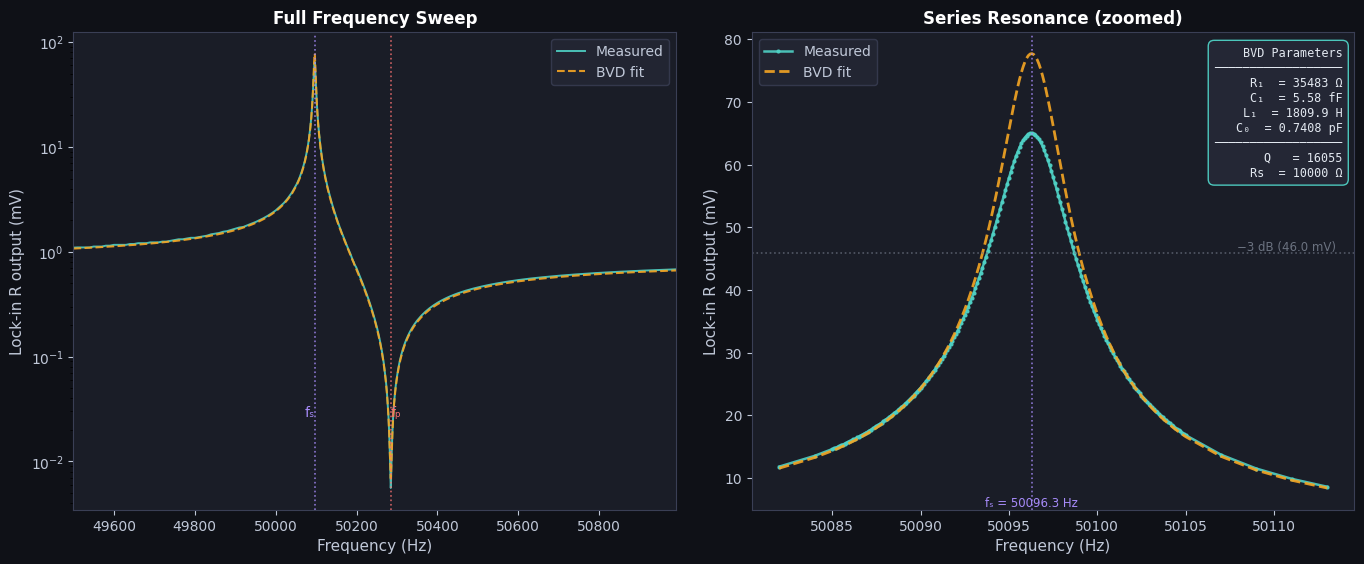

In [3]:
# ---------------------------------------------------------
# 5. VISUALIZATION (Dark Mode & Dual Plot Slay)
# ---------------------------------------------------------
V_fit = BVD_voltage_divider(freq, R1_final, C0_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#c0c8d8', labelsize=10)
    ax.spines[:].set_color('#3a3f55')
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

CYAN = '#4fd1c5'
ORANGE = '#f6a623'
GRAY = '#6b7280'

# --- Left: full sweep ---
ax1 = axes[0]
ax1.semilogy(freq, V_meas*1000, color=CYAN, lw=1.4, label='Measured', alpha=0.9)
ax1.semilogy(freq, V_fit*1000, color=ORANGE, lw=1.5, ls='--', label='BVD fit', alpha=0.9)
ax1.axvline(fs, color='#a78bfa', ls=':', lw=1.2, alpha=0.8)
ax1.axvline(fp, color='#f87171', ls=':', lw=1.2, alpha=0.8)
ax1.text(fs, 0.025, 'fₛ', color='#a78bfa', fontsize=10, ha='right', va='bottom')
ax1.text(fp, 0.025, 'fₚ', color='#f87171', fontsize=10, ha='left', va='bottom')
ax1.set_xlabel('Frequency (Hz)', color='#c0c8d8', fontsize=11)
ax1.set_ylabel('Lock-in R output (mV)', color='#c0c8d8', fontsize=11)
ax1.set_title('Full Frequency Sweep', color='white', fontsize=12, fontweight='bold')
ax1.legend(facecolor='#252836', edgecolor='#3a3f55', labelcolor='#c0c8d8', fontsize=10)
ax1.set_xlim(freq.min(), freq.max())

# --- Right: zoom on resonance peak ---
ax2 = axes[1]
mask = (freq > 50080) & (freq < 50115)
ax2.plot(freq[mask], V_meas[mask]*1000, color=CYAN, lw=1.8, label='Measured', marker='o', ms=2, alpha=0.9)
ax2.plot(freq[mask], V_fit[mask]*1000, color=ORANGE, lw=2, ls='--', label='BVD fit', alpha=0.9)

# Mark 3dB points
V_peak_mV = V_meas.max()*1000
V_3dB_mV = V_peak_mV / np.sqrt(2)
ax2.axhline(V_3dB_mV, color=GRAY, ls=':', lw=1.2, alpha=0.7)
ax2.text(50113.5, V_3dB_mV+0.3, f'−3 dB ({V_3dB_mV:.1f} mV)', 
         color=GRAY, fontsize=8.5, ha='right')
ax2.axvline(fs, color='#a78bfa', ls=':', lw=1.2, alpha=0.8)
ax2.text(fs, 5, f'fₛ = {fs} Hz', color='#a78bfa', fontsize=8.5, ha='center', va='bottom')

ax2.set_xlabel('Frequency (Hz)', color='#c0c8d8', fontsize=11)
ax2.set_ylabel('Lock-in R output (mV)', color='#c0c8d8', fontsize=11)
ax2.set_title('Series Resonance (zoomed)', color='white', fontsize=12, fontweight='bold')
ax2.legend(facecolor='#252836', edgecolor='#3a3f55', labelcolor='#c0c8d8', fontsize=10)

# Annotation box with results
box_text = (
    f"BVD Parameters\n"
    f"──────────────────\n"
    f"R₁  = {R1_final:.0f} Ω\n"
    f"C₁  = {C1_final*1e15:.2f} fF\n"
    f"L₁  = {L1_final:.1f} H\n"
    f"C₀  = {C0_final*1e12:.4f} pF\n"
    f"──────────────────\n"
    f"Q   = {Q_final:.0f}\n"
    f"Rs  = {Rs:.0f} Ω"
)
ax2.text(0.98, 0.97, box_text, transform=ax2.transAxes,
         fontsize=8.5, va='top', ha='right', color='#e2e8f0',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#252836', 
                   edgecolor='#4fd1c5', alpha=0.95),
         fontfamily='monospace')

plt.tight_layout(pad=2)
plt.show()

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ---------------------------------------------------------
# 1. LOAD DATA & SET CONSTANTS
# ---------------------------------------------------------
df = pd.read_csv('processed_data.csv')
freq = df['frequency_Hz'].values
V_meas = df['R_V_mean'].values

# The exact circuit parameters
V_source = 0.5 / np.sqrt(2)  # 1Vpp to Vrms
Rs = 10000.0                 # The known 10k Ohm sense resistor

# The observed resonance frequencies
fs = 50096.3
fp = 50284.5

# Analytical constraint: C1/C0 ratio derived from fs and fp
C1_C0_ratio = (fp / fs)**2 - 1 

# ---------------------------------------------------------
# 2. THE THEORETICAL MODEL
# ---------------------------------------------------------
def BVD_voltage_divider(f, R1, C0):
    """Calculates the voltage across Rs given R1 and C0, using analytical constraints."""
    # Derive C1 and L1 strictly from C0 and the known frequencies
    C1 = C1_C0_ratio * C0
    ws = 2 * np.pi * fs
    L1 = 1.0 / (ws**2 * C1)
    
    # Angular frequency array
    w = 2 * np.pi * f
    
    # BVD Impedances
    Z_m = R1 + 1j * (w * L1 - 1.0 / (w * C1))
    Z_C0 = 1.0 / (1j * w * C0)
    Z_xtal = (Z_m * Z_C0) / (Z_m + Z_C0)
    
    # Expected voltage across the sense resistor
    V_pred = V_source * Rs / np.abs(Rs + Z_xtal)
    return V_pred

def objective_function(params):
    """Calculates the logarithmic residual between the model and the data."""
    R1 = np.exp(params[0])  # Optimize in log-space for stability
    C0 = np.exp(params[1])
    
    V_pred = BVD_voltage_divider(freq, R1, C0)
    
    # Log-scale is used to equally weight the peak and the noise-floor dip
    residuals = np.log(V_pred + 1e-10) - np.log(V_meas + 1e-10)
    return np.sum(residuals**2)

# ---------------------------------------------------------
# 3. OPTIMIZATION
# ---------------------------------------------------------
# Initial guesses based on peak amplitude and baseline
x0 = [np.log(35000), np.log(1e-12)]

print("Optimizing parameters (R1, C0)...")
res = minimize(
    objective_function, 
    x0, 
    method='Nelder-Mead', 
    options={'maxiter': 50000, 'xatol': 1e-10, 'fatol': 1e-12}
)

# ---------------------------------------------------------
# 4. EXTRACT & PRINT RESULTS
# ---------------------------------------------------------
R1_final = np.exp(res.x[0])
C0_final = np.exp(res.x[1])

# Back-calculate the dependent variables
C1_final = C1_C0_ratio * C0_final
L1_final = 1.0 / ((2 * np.pi * fs)**2 * C1_final)
Q_final = (2 * np.pi * fs * L1_final) / R1_final

print("\n=== FINAL CRYSTAL PARAMETERS ===")
print(f"R1 (Motional Resistance) = {R1_final:.1f} Ω")
print(f"C1 (Motional Capacitance) = {C1_final*1e15:.3f} fF")
print(f"L1 (Motional Inductance) = {L1_final:.2f} H")
print(f"C0 (Static Capacitance) = {C0_final*1e12:.4f} pF")
print(f"Q  (Quality Factor) = {Q_final:.0f}")

Optimizing parameters (R1, C0)...

=== FINAL CRYSTAL PARAMETERS ===
R1 (Motional Resistance) = 35483.3 Ω
C1 (Motional Capacitance) = 5.577 fF
L1 (Motional Inductance) = 1809.85 H
C0 (Static Capacitance) = 0.7408 pF
Q  (Quality Factor) = 16055


Optimizing parameters (R1, C0)...

=== FINAL CRYSTAL PARAMETERS ===
R1 = 35483.3 Ω
C1 = 5.577 fF
L1 = 1809.85 H
C0 = 0.7408 pF
Q  = 16055


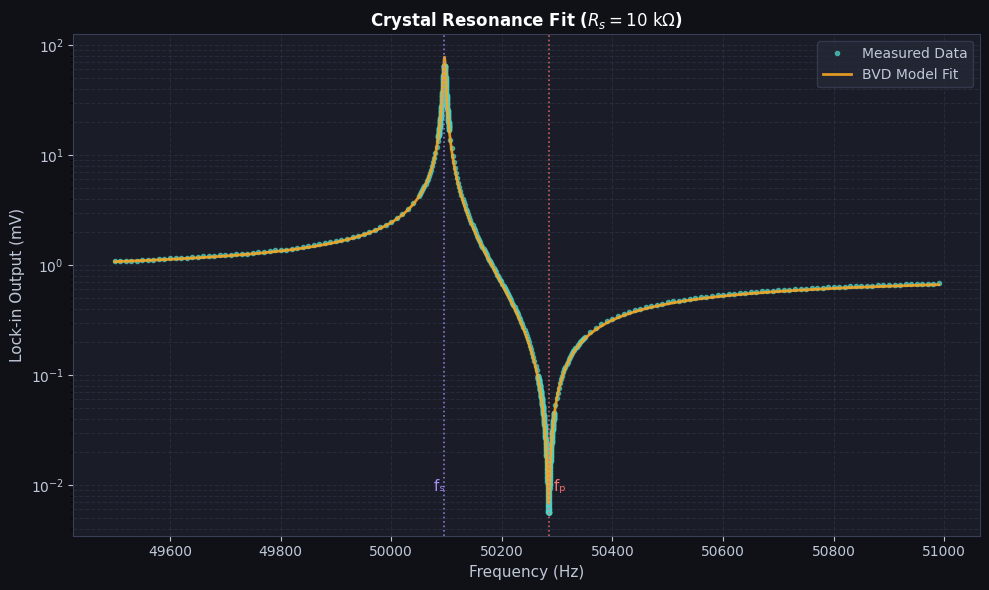

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ---------------------------------------------------------
# 1. LOAD DATA & SET CONSTANTS
# ---------------------------------------------------------
df = pd.read_csv('processed_data.csv')
freq = df['frequency_Hz'].values
V_meas = df['R_V_mean'].values

# The exact circuit parameters
V_source = 0.5 / np.sqrt(2)  # 1Vpp to Vrms
Rs = 10000.0                 # The known 10k Ohm sense resistor

# The observed resonance frequencies
fs = 50096.3
fp = 50284.5

# Analytical constraint: C1/C0 ratio derived from fs and fp
C1_C0_ratio = (fp / fs)**2 - 1 

# ---------------------------------------------------------
# 2. THE THEORETICAL MODEL
# ---------------------------------------------------------
def BVD_voltage_divider(f, R1, C0):
    """Calculates the voltage across Rs given R1 and C0, using analytical constraints."""
    C1 = C1_C0_ratio * C0
    ws = 2 * np.pi * fs
    L1 = 1.0 / (ws**2 * C1)
    
    w = 2 * np.pi * f
    Z_m = R1 + 1j * (w * L1 - 1.0 / (w * C1))
    Z_C0 = 1.0 / (1j * w * C0)
    Z_xtal = (Z_m * Z_C0) / (Z_m + Z_C0)
    
    V_pred = V_source * Rs / np.abs(Rs + Z_xtal)
    return V_pred

def objective_function(params):
    """Calculates the logarithmic residual between the model and the data."""
    R1 = np.exp(params[0])  
    C0 = np.exp(params[1])
    V_pred = BVD_voltage_divider(freq, R1, C0)
    residuals = np.log(V_pred + 1e-10) - np.log(V_meas + 1e-10)
    return np.sum(residuals**2)

# ---------------------------------------------------------
# 3. OPTIMIZATION
# ---------------------------------------------------------
x0 = [np.log(35000), np.log(1e-12)]

print("Optimizing parameters (R1, C0)...")
res = minimize(
    objective_function, 
    x0, 
    method='Nelder-Mead', 
    options={'maxiter': 50000, 'xatol': 1e-10, 'fatol': 1e-12}
)

R1_final = np.exp(res.x[0])
C0_final = np.exp(res.x[1])
C1_final = C1_C0_ratio * C0_final
L1_final = 1.0 / ((2 * np.pi * fs)**2 * C1_final)
Q_final = (2 * np.pi * fs * L1_final) / R1_final

print("\n=== FINAL CRYSTAL PARAMETERS ===")
print(f"R1 = {R1_final:.1f} Ω")
print(f"C1 = {C1_final*1e15:.3f} fF")
print(f"L1 = {L1_final:.2f} H")
print(f"C0 = {C0_final*1e12:.4f} pF")
print(f"Q  = {Q_final:.0f}")

# ---------------------------------------------------------
# 4. VISUALIZATION (The Cute Dark Theme)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

# Styling ticks and spines
ax.tick_params(colors='#c0c8d8', labelsize=10)
ax.spines[:].set_color('#3a3f55')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)

CYAN = '#4fd1c5'
ORANGE = '#f6a623'

# Plotting the data
ax.semilogy(freq, V_meas * 1000, 'o', color=CYAN, markersize=3, label='Measured Data', alpha=0.7)
ax.semilogy(freq, BVD_voltage_divider(freq, R1_final, C0_final) * 1000, '-', color=ORANGE, lw=2, label='BVD Model Fit', alpha=0.9)

# Marking the resonance frequencies
ax.axvline(fs, color='#a78bfa', ls=':', lw=1.2, alpha=0.8)
ax.axvline(fp, color='#f87171', ls=':', lw=1.2, alpha=0.8)
# Placing text slightly above the bottom of the plot so it doesn't overlap the axis
y_text_pos = np.min(V_meas * 1000) * 1.5 
ax.text(fs, y_text_pos, ' fₛ', color='#a78bfa', fontsize=11, ha='right', va='bottom')
ax.text(fp, y_text_pos, ' fₚ', color='#f87171', fontsize=11, ha='left', va='bottom')

# Labels and Title
ax.set_xlabel('Frequency (Hz)', color='#c0c8d8', fontsize=11)
ax.set_ylabel('Lock-in Output (mV)', color='#c0c8d8', fontsize=11)
ax.set_title('Crystal Resonance Fit ($R_s = 10\\text{ k}\\Omega$)', color='white', fontsize=12, fontweight='bold')

# Legend and Grid
ax.legend(facecolor='#252836', edgecolor='#3a3f55', labelcolor='#c0c8d8', fontsize=10)
ax.grid(True, which="both", color='#3a3f55', ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [6]:
BVD_voltage_divider(50096.3, R1_final, C0_final)

np.float64(0.07773511076050162)

Optimizing parameters (R1, C0)...


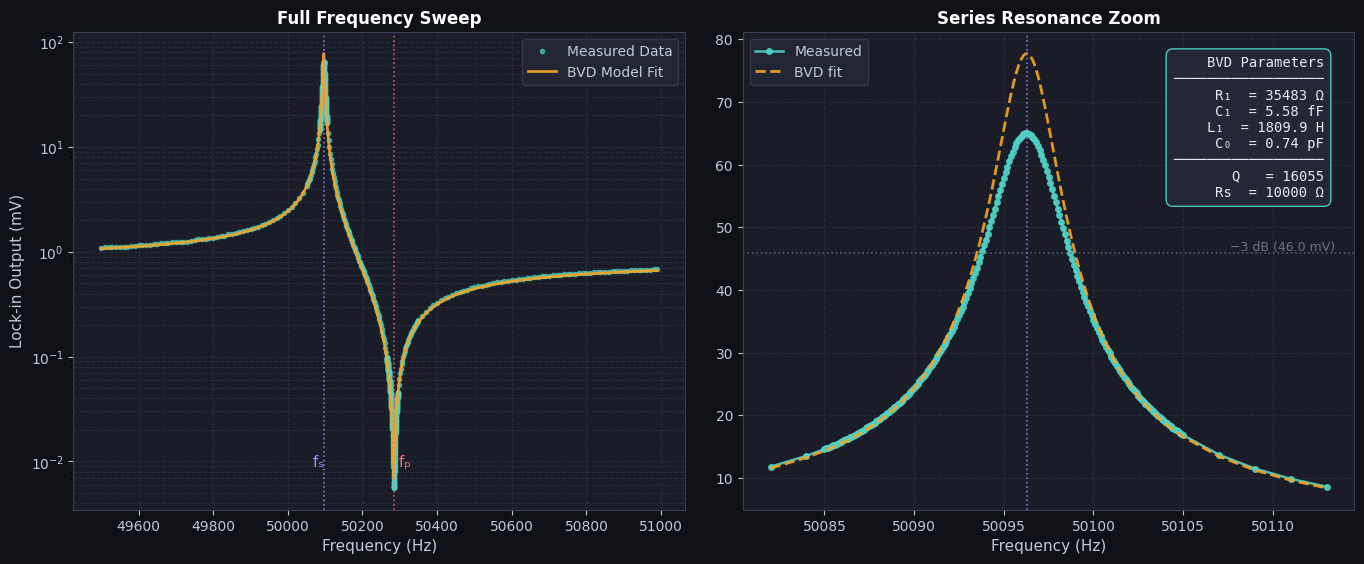

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ---------------------------------------------------------
# 1. LOAD DATA & SET CONSTANTS
# ---------------------------------------------------------
df = pd.read_csv('processed_data.csv')
freq = df['frequency_Hz'].values
V_meas = df['R_V_mean'].values

# The exact circuit parameters
V_source = 0.5 / np.sqrt(2)  # 1Vpp to Vrms
Rs = 10000.0                 # The known 10k Ohm sense resistor

# The observed resonance frequencies
fs = 50096.3
fp = 50284.5

# Analytical constraint: C1/C0 ratio derived from fs and fp
C1_C0_ratio = (fp / fs)**2 - 1 

# ---------------------------------------------------------
# 2. THE THEORETICAL MODEL
# ---------------------------------------------------------
def BVD_voltage_divider(f, R1, C0):
    C1 = C1_C0_ratio * C0
    ws = 2 * np.pi * fs
    L1 = 1.0 / (ws**2 * C1)
    
    w = 2 * np.pi * f
    Z_m = R1 + 1j * (w * L1 - 1.0 / (w * C1))
    Z_C0 = 1.0 / (1j * w * C0)
    Z_xtal = (Z_m * Z_C0) / (Z_m + Z_C0)
    
    V_pred = V_source * Rs / np.abs(Rs + Z_xtal)
    return V_pred

def objective_function(params):
    R1 = np.exp(params[0])  
    C0 = np.exp(params[1])
    V_pred = BVD_voltage_divider(freq, R1, C0)
    residuals = np.log(V_pred + 1e-10) - np.log(V_meas + 1e-10)
    return np.sum(residuals**2)

# ---------------------------------------------------------
# 3. OPTIMIZATION
# ---------------------------------------------------------
x0 = [np.log(35000), np.log(1e-12)]

print("Optimizing parameters (R1, C0)...")
res = minimize(
    objective_function, 
    x0, 
    method='Nelder-Mead', 
    options={'maxiter': 50000, 'xatol': 1e-10, 'fatol': 1e-12}
)

R1_final = np.exp(res.x[0])
C0_final = np.exp(res.x[1])
C1_final = C1_C0_ratio * C0_final
L1_final = 1.0 / ((2 * np.pi * fs)**2 * C1_final)
Q_final = (2 * np.pi * fs * L1_final) / R1_final

V_fit = BVD_voltage_divider(freq, R1_final, C0_final)

# ---------------------------------------------------------
# 4. VISUALIZATION (Dark Theme + Zoom)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#c0c8d8', labelsize=10)
    ax.spines[:].set_color('#3a3f55')
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

CYAN = '#4fd1c5'
ORANGE = '#f6a623'
GRAY = '#6b7280'

# --- Left: Full Sweep ---
ax1 = axes[0]
ax1.semilogy(freq, V_meas * 1000, 'o', color=CYAN, markersize=3, label='Measured Data', alpha=0.7)
ax1.semilogy(freq, V_fit * 1000, '-', color=ORANGE, lw=2, label='BVD Model Fit', alpha=0.9)
ax1.axvline(fs, color='#a78bfa', ls=':', lw=1.2, alpha=0.8)
ax1.axvline(fp, color='#f87171', ls=':', lw=1.2, alpha=0.8)

y_text_pos = np.min(V_meas * 1000) * 1.5 
ax1.text(fs, y_text_pos, ' fₛ', color='#a78bfa', fontsize=11, ha='right', va='bottom')
ax1.text(fp, y_text_pos, ' fₚ', color='#f87171', fontsize=11, ha='left', va='bottom')

ax1.set_xlabel('Frequency (Hz)', color='#c0c8d8', fontsize=11)
ax1.set_ylabel('Lock-in Output (mV)', color='#c0c8d8', fontsize=11)
ax1.set_title('Full Frequency Sweep', color='white', fontsize=12, fontweight='bold')
ax1.legend(facecolor='#252836', edgecolor='#3a3f55', labelcolor='#c0c8d8', fontsize=10)
ax1.grid(True, which="both", color='#3a3f55', ls="--", alpha=0.4)

# --- Right: Zoomed Peak ---
ax2 = axes[1]
mask = (freq > 50080) & (freq < 50115)
ax2.plot(freq[mask], V_meas[mask] * 1000, color=CYAN, lw=1.8, label='Measured', marker='o', ms=4, alpha=0.9)
ax2.plot(freq[mask], V_fit[mask] * 1000, color=ORANGE, lw=2, ls='--', label='BVD fit', alpha=0.9)

# Mark 3dB points on the zoom
V_peak_mV = V_meas.max() * 1000
V_3dB_mV = V_peak_mV / np.sqrt(2)
ax2.axhline(V_3dB_mV, color=GRAY, ls=':', lw=1.2, alpha=0.7)
ax2.text(50113.5, V_3dB_mV + 0.3, f'−3 dB ({V_3dB_mV:.1f} mV)', color=GRAY, fontsize=9, ha='right')
ax2.axvline(fs, color='#a78bfa', ls=':', lw=1.2, alpha=0.8)

ax2.set_xlabel('Frequency (Hz)', color='#c0c8d8', fontsize=11)
ax2.set_title('Series Resonance Zoom', color='white', fontsize=12, fontweight='bold')
ax2.legend(facecolor='#252836', edgecolor='#3a3f55', labelcolor='#c0c8d8', fontsize=10)
ax2.grid(True, color='#3a3f55', ls="--", alpha=0.4)

# Put the final parameters in a cute box
box_text = (
    f"BVD Parameters\n"
    f"──────────────────\n"
    f"R₁  = {R1_final:.0f} Ω\n"
    f"C₁  = {C1_final*1e15:.2f} fF\n"
    f"L₁  = {L1_final:.1f} H\n"
    f"C₀  = {C0_final*1e12:.2f} pF\n"
    f"──────────────────\n"
    f"Q   = {Q_final:.0f}\n"
    f"Rs  = 10000 Ω"
)
ax2.text(0.95, 0.95, box_text, transform=ax2.transAxes,
         fontsize=10, va='top', ha='right', color='#e2e8f0',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#252836', 
                   edgecolor='#4fd1c5', alpha=0.95),
         fontfamily='monospace')

plt.tight_layout(pad=2)
plt.show()

In [12]:
from scipy.optimize import least_squares

def residuals_vec(params):
    R1 = np.exp(params[0])
    C0 = np.exp(params[1])
    V_pred = BVD_voltage_divider(freq, R1, C0)
    return (V_pred - V_meas) / V_err   # vector, not sum

res = least_squares(residuals_vec, x0, method='lm', 
                    ftol=1e-12, xtol=1e-10, max_nfev=50000)

# Covariance matrix from the Jacobian
J = res.jac
chi2_red = np.sum(res.fun**2) / (len(V_meas) - 2)   # reduced chi-squared
cov = np.linalg.inv(J.T @ J) * chi2_red              # in log-space

# Uncertainties (still in log-space, propagate out)
sigma_lnR1, sigma_lnC0 = np.sqrt(np.diag(cov))

R1_final = np.exp(res.x[0])
C0_final = np.exp(res.x[1])

# Since param = exp(ln_param), σ_param ≈ param * σ_ln_param
R1_err = R1_final * sigma_lnR1
C0_err = C0_final * sigma_lnC0

# Propagate to derived quantities
C1_final = C1_C0_ratio * C0_final
C1_err   = C1_C0_ratio * C0_err

L1_final = 1.0 / ((2 * np.pi * fs)**2 * C1_final)
L1_err   = L1_final * (C1_err / C1_final)   # L1 ∝ 1/C1

Q_final  = (2 * np.pi * fs * L1_final) / R1_final
Q_err    = Q_final * np.sqrt((L1_err/L1_final)**2 + (R1_err/R1_final)**2)

print(f"R1 = {R1_final:.2f} ± {R1_err:.2f} Ω")
print(f"C0 = {C0_final*1e12:.4f} ± {C0_err*1e12:.4f} pF")
print(f"C1 = {C1_final*1e15:.4f} ± {C1_err*1e15:.4f} fF")
print(f"L1 = {L1_final:.4f} ± {L1_err:.4f} H")
print(f"Q  = {Q_final:.1f} ± {Q_err:.1f}")

R1 = 35557.24 ± 275.57 Ω
C0 = 0.7377 ± 0.0015 pF
C1 = 5.5531 ± 0.0115 fF
L1 = 1817.5914 ± 3.7739 H
Q  = 16089.9 ± 129.1
